In [15]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
df = pd.read_csv("housing.csv")

In [17]:
# RANSAC doesn't work with datasets with missing  values...
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [18]:
df = df.dropna()

In [19]:
# Also it will be too many outliers if we will keep rows with house value - 500001:
df = df[df['median_house_value'] < 500001]
df['median_house_value'].value_counts().sort_index()

median_house_value
14999.0      4
17500.0      1
22500.0      4
25000.0      1
26600.0      1
            ..
498700.0     1
498800.0     1
499000.0     1
499100.0     1
500000.0    27
Name: count, Length: 3832, dtype: int64

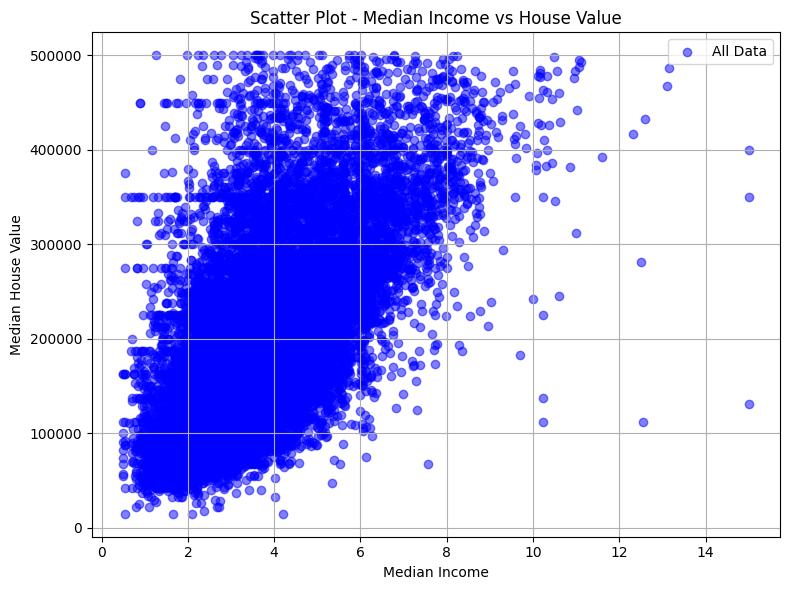

In [20]:
import matplotlib.pyplot as plt

# Scatter plot of original housing data before any filtering
plt.figure(figsize=(8, 6))
plt.scatter(df['median_income'], df['median_house_value'],
            color='blue', alpha=0.5, label='All Data')

plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title("Scatter Plot - Median Income vs House Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# drop unneeded non-numeric columns:
columns_to_drop = ['longitude', 'latitude', 'ocean_proximity']
housing_ransac = df.drop(columns=columns_to_drop).copy()

# Split into features (X) and target (y)
X = housing_ransac.drop("median_house_value", axis=1)
y = housing_ransac["median_house_value"]

In [22]:
# Apply RANSAC:
# initalize RANSAC regressor and fit our data
# RANSAC needs a threshold in order to process data
# since our data is heavily skewed, we're gonna use this trick
ransac = RANSACRegressor(residual_threshold=np.std(y) * 1.5)
ransac.fit(X, y)

# now we have split the result into 
# inliers and outliers
# inliers => good data, follows the distribution nicely
# outliers => are far away from the main distribution
# the ~-sign (tilde) in pandas DataFrames means "the opposite of"
# so in this case => get everything from DataFrame EXCEPT the inliers
inlier_mask = ransac.inlier_mask_
outliers = housing_ransac[~inlier_mask]
inliers = housing_ransac[inlier_mask]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")


Inliers: 17420
Outliers: 2055


In [23]:

housing_ransac.columns

Index(['housing_median_age', 'total_rooms', 'total_bedrooms', 'population',
       'households', 'median_income', 'median_house_value'],
      dtype='object')

In [24]:
#ransac = RANSACRegressor(
#    estimator=LinearRegression(),
#    min_samples=50,
#    max_trials=100,
#    loss='absolute_error',
#    residual_threshold=100000,  # in housing prices, 10 is too small
#    random_state=42
#)

#ransac.fit(X, y)

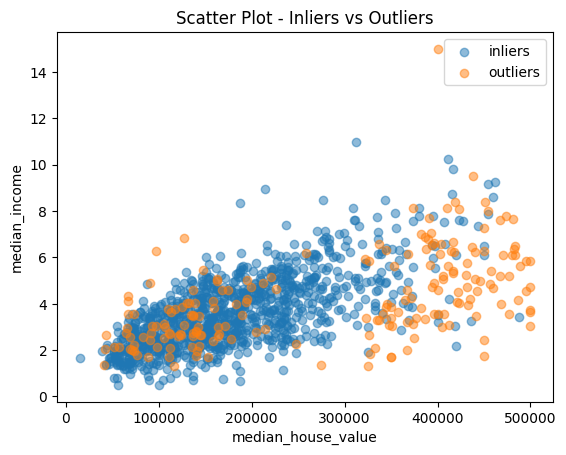

In [25]:
import matplotlib.pyplot as plt

variable = "median_house_value"
target = "median_income"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(1000)
outliers_sample = outliers.sample(200)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

<Axes: xlabel='median_house_value', ylabel='Count'>

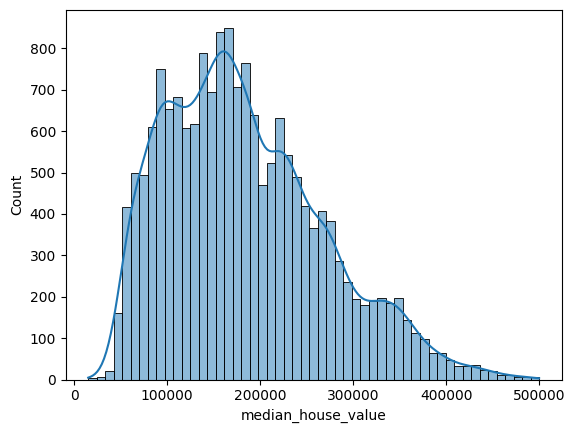

In [26]:

sns.histplot(data=inliers, x="median_house_value", kde=True)

<Axes: xlabel='median_income', ylabel='Count'>

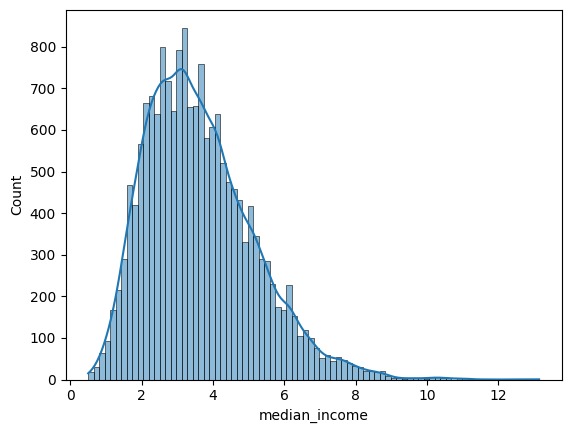

In [27]:
sns.histplot(data=inliers, x="median_income", kde=True)

<Axes: xlabel='total_rooms', ylabel='Count'>

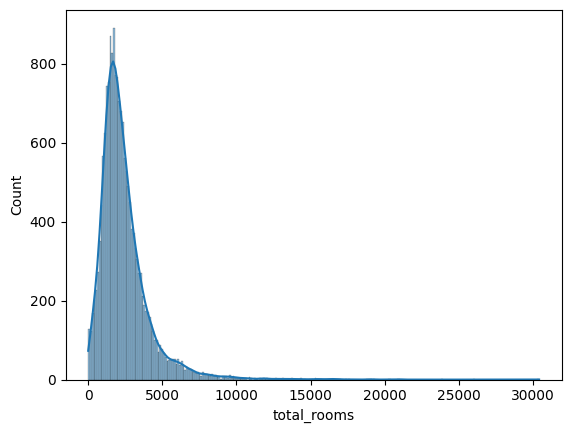

In [28]:
sns.histplot(data=inliers, x="total_rooms", kde=True)

<Axes: xlabel='population', ylabel='Count'>

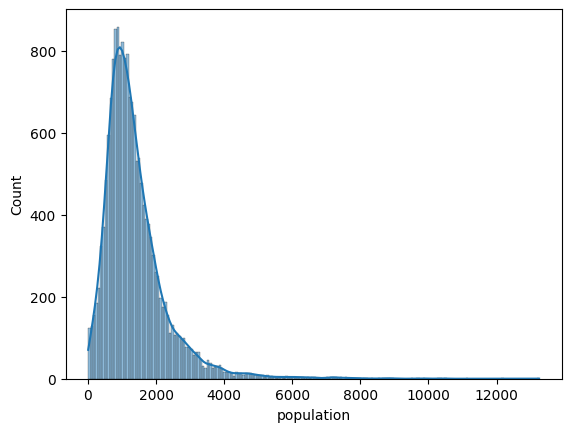

In [31]:
sns.histplot(data=inliers, x="population", kde=True)


In [30]:
housing_ransac.describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19475.000000,19475.000000,19475.000000,19475.000000,19475.000000,19475.000000,19475.000000
mean,28.378074,2620.491142,539.645751,1440.290732,501.093504,3.676739,192444.651913
std,12.515373,2184.938093,422.413200,1144.399323,383.206416,1.569263,97702.625782
min,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,18.000000,1441.000000,297.000000,796.000000,282.000000,2.526500,116500.000000
50%,28.000000,2111.000000,436.000000,1178.000000,411.000000,3.451900,173800.000000
75%,37.000000,3118.000000,648.000000,1743.000000,606.000000,4.583300,248100.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500000.000000
